In [522]:
!curl -O https://raw.githubusercontent.com/gentleman644/foxtrot-thyroid-cancer-prediction/refs/heads/Test/UnitTest.py
# unitTestPath = os.path.join(os.getcwd(), "UnitTest.py")
%run -i "UnitTest.py"

# Imports and load dataset
import importlib
import UnitTest
importlib.reload(UnitTest)

from UnitTest import TestMethods as tm
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load dataset
dataset = pd.read_csv("https://github.com/gentleman644/foxtrot-thyroid-cancer-prediction/blob/main/thyroid_cancer_risk_data.csv?raw=true",
            header=0, index_col=0)

# Preview dataset 1
print(dataset.head(), "\n") #first 5 rows
print(dataset.tail(), "\n") #last 5 rows
tm.test_load_data(dataset)

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100   1103 100   1103   0      0   7099      0                              0
100   1103 100   1103   0      0   7094      0                              0
100   1103 100   1103   0      0   7088      0                              0


            Age  Gender  Country  Ethnicity Family_History Radiation_Exposure Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  T3_Level  T4_Level  Nodule_Size Thyroid_Cancer_Risk Diagnosis
Patient_ID                                                                                                                                                                                        
1            66    Male   Russia  Caucasian             No                Yes                No      No      No       No       9.37      1.67      6.16         1.08                 Low    Benign
2            29    Male  Germany   Hispanic             No                Yes                No      No      No       No       1.83      1.73     10.54         4.05                 Low    Benign
3            86    Male  Nigeria  Caucasian             No                 No                No      No      No       No       6.26      2.59     10.57         4.61                 Low    Benign
4            75  Female  

In [523]:
from pandas.api.types import is_numeric_dtype
# Preview data features and figure out problems for data preprocessing
# P1: 11 non-numeric features, which need to be encoded before feeding into ML models
# P2: Class imbalance in the target variable (Diagnosis), which requires oversampling
print(dataset.info(), "\n")
print(dataset.describe(), "\n")

print("Count of each non-numeric feature:")
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        print(f"{col:<24}({dataset[col].dtype}): {len(dataset[col])}")

print("\nCount of each class in the target variable:")
print(dataset["Diagnosis"].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 212691 entries, 1 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  212691 non-null  int64  
 1   Gender               212691 non-null  object 
 2   Country              212691 non-null  object 
 3   Ethnicity            212691 non-null  object 
 4   Family_History       212691 non-null  object 
 5   Radiation_Exposure   212691 non-null  object 
 6   Iodine_Deficiency    212691 non-null  object 
 7   Smoking              212691 non-null  object 
 8   Obesity              212691 non-null  object 
 9   Diabetes             212691 non-null  object 
 10  TSH_Level            212691 non-null  float64
 11  T3_Level             212691 non-null  float64
 12  T4_Level             212691 non-null  float64
 13  Nodule_Size          212691 non-null  float64
 14  Thyroid_Cancer_Risk  212691 non-null  object 
 15  Diagnosis            2

## Data Preprocessing - Feature Encoding
*Write any notes or observations about the feature encoding process here if you want*

In [524]:
# P1: Encode all non-numeric features (use OrdinalEncoder)
# (Transform all non-numeric features into numeric features, so that we can feed them into ML models)
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories="auto")
dataset_encoded = dataset.copy()
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        dataset_encoded[col] = ordinal_encoder.fit_transform(dataset[[col]])

print(dataset_encoded.info(), "\n")
print(dataset_encoded.head(), "\n")
print(dataset_encoded.tail(), "\n")

print(f"{'Category':<13} | {'Count':<8} | {'Encoded':<6} | {'Count':<8}")
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        # Print value counts of original vs encoded, one line each after the other
        print(f"--{col}--")
        original_counts = dataset[col].value_counts().to_dict()
        encoded_counts = dataset_encoded[col].value_counts().to_dict()
        for category in original_counts.keys():
            original_count = original_counts[category]
            encoded_category = dataset_encoded[col].loc[dataset[col].index[dataset[col] == category][0]]
            encoded_count = encoded_counts[encoded_category] if encoded_category is not None else None
            print(f"{str(category):<14}: {original_count:<8} | {str(encoded_category):<8}: {encoded_count:<6}")

dataset = dataset_encoded.copy()
tm.test_ordinal_encoder(dataset)


<class 'pandas.core.frame.DataFrame'>
Index: 212691 entries, 1 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  212691 non-null  int64  
 1   Gender               212691 non-null  float64
 2   Country              212691 non-null  float64
 3   Ethnicity            212691 non-null  float64
 4   Family_History       212691 non-null  float64
 5   Radiation_Exposure   212691 non-null  float64
 6   Iodine_Deficiency    212691 non-null  float64
 7   Smoking              212691 non-null  float64
 8   Obesity              212691 non-null  float64
 9   Diabetes             212691 non-null  float64
 10  TSH_Level            212691 non-null  float64
 11  T3_Level             212691 non-null  float64
 12  T4_Level             212691 non-null  float64
 13  Nodule_Size          212691 non-null  float64
 14  Thyroid_Cancer_Risk  212691 non-null  float64
 15  Diagnosis            2

## Data Preprocessing - Target Variable Class Imbalance
*Write any notes or observations about the target variable class imbalance process here if you want*

In [525]:
# P2: Class imbalance in the target variable (Diagnosis), which requires baalancing
from imblearn.under_sampling import RandomUnderSampler

# 1. Verify columns & class imbalance
print(f"Starting column is '{dataset.columns[0]}'")
print(f"Target variable is '{dataset.columns[15]}'")
print(dataset['Diagnosis'].value_counts())

# 2. Separate features and target variable
feats_X = dataset.iloc[:, :15]
trgt_y = dataset.iloc[:, 15]

# 3. Apply Random Undersampling
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
resmpl_X, resmpl_y = rus.fit_resample(feats_X, trgt_y)

# 4. Recombine into a single dataframe
dataset = pd.concat([resmpl_X, resmpl_y], axis=1)

# 5. Verify results
print(resmpl_y.value_counts())
print(dataset.info())
print(dataset.head())
tm.test_target_class_imbalance(resmpl_y)

Starting column is 'Age'
Target variable is 'Diagnosis'
Diagnosis
0.0    49495
1.0    49495
Name: count, dtype: int64
Diagnosis
0.0    49495
1.0    49495
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 98990 entries, 202232 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  98990 non-null  int64  
 1   Gender               98990 non-null  float64
 2   Country              98990 non-null  float64
 3   Ethnicity            98990 non-null  float64
 4   Family_History       98990 non-null  float64
 5   Radiation_Exposure   98990 non-null  float64
 6   Iodine_Deficiency    98990 non-null  float64
 7   Smoking              98990 non-null  float64
 8   Obesity              98990 non-null  float64
 9   Diabetes             98990 non-null  float64
 10  TSH_Level            98990 non-null  float64
 11  T3_Level             98990 non-null  float64
 12  T4_Le

## Data visualization - Preview dataset
*Write any notes or observations about the dataset preview here if you want*

Determine any skewness in the dataset, and any problems that need to be handled in data preprocessing.

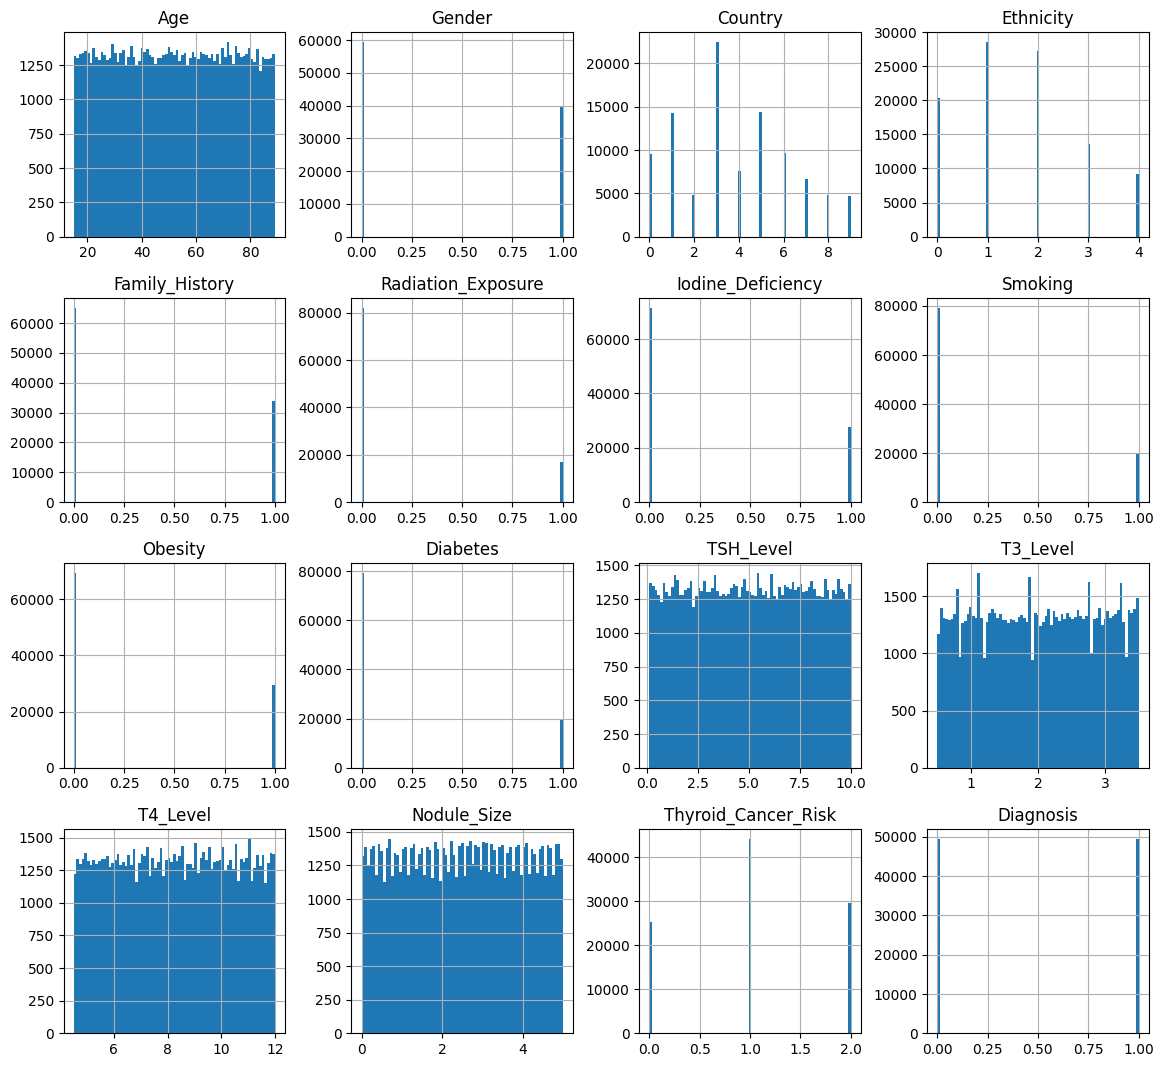

In [526]:
# Part 4: Data graphs

# Graphical: Preview dataset 1
import matplotlib.pyplot as plt

dataset.hist(bins=75, figsize=(14, 13))
plt.show()

# Graphical: Preview dataset 2
from pandas.plotting import scatter_matrix
attributes = []
for col in dataset.columns:
    attributes.append(col)
# scatter matrix takes a long time to run so commented out for now
# scatter_matrix(dataset[attributes], alpha=0.9, figsize=(17, 15), diagonal='kde')

In [527]:
# Feature engineering steps

# Feature Identification ------
# Convert dataframe to float type
# Select input and target features (feats_X and trgt_y)

dataset = dataset.astype("float64")  # Convert pandas-dataframe to "float" type
feats_X = dataset.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]]
print("Features (Inputs or Independent variables):", feats_X.shape, "\n")

trgt_y = pd.DataFrame(dataset.iloc[:, 15])
print("Targets (Outputs or Dependent variables):", trgt_y.shape)

Features (Inputs or Independent variables): (98990, 15) 

Targets (Outputs or Dependent variables): (98990, 1)


In [528]:
# Feature Engineering using np.where to safely bypass division by zero.
# np.where(condition, value_if_true, value_if_false)

#Checkoung for 0 before division in the following features
feats_X["TSH_Level per Nodule_Size"] = np.where(
    feats_X["Nodule_Size"] == 0, 
    0,
    feats_X["TSH_Level"] / feats_X["Nodule_Size"]
)

feats_X["T3_Level per Nodule_Size"] = np.where(
    feats_X["Nodule_Size"] == 0, 
    0, 
    feats_X["T3_Level"] / feats_X["Nodule_Size"]
)

feats_X["T4_Level per Nodule_Size"] = np.where(
    feats_X["Nodule_Size"] == 0, 
    0, 
    feats_X["T4_Level"] / feats_X["Nodule_Size"]
)

print(feats_X.head(), "\n")
print(feats_X.tail(), "\n")
print(feats_X.info(), "\n")


# This should now safely print an empty list: []
indices = np.where(np.isinf(feats_X) | np.isnan(feats_X))
print("'NaN' or 'inf' indices (row, column): ", list(zip(*indices)))

             Age  Gender  Country  Ethnicity  Family_History  Radiation_Exposure  Iodine_Deficiency  Smoking  Obesity  Diabetes  TSH_Level  T3_Level  T4_Level  Nodule_Size  Thyroid_Cancer_Risk  TSH_Level per Nodule_Size  T3_Level per Nodule_Size  T4_Level per Nodule_Size
Patient_ID                                                                                                                                                                                                                                                                     
124276      51.0     1.0      6.0        2.0             0.0                 0.0                0.0      0.0      1.0       0.0       6.84      3.25      7.26         3.09                  1.0                   2.213592                  1.051780                  2.349515
158423      40.0     1.0      6.0        2.0             1.0                 0.0                0.0      0.0      1.0       0.0       0.82      3.35     11.07         1.63             

                     Feature         Score
14       Thyroid_Cancer_Risk  15529.195864
4             Family_History   2575.527969
3                  Ethnicity   1560.589219
6          Iodine_Deficiency   1238.454045
5         Radiation_Exposure   1013.023187
2                    Country     85.421983
10                 TSH_Level      3.526569
11                  T3_Level      2.878972
9                   Diabetes      2.783972
13               Nodule_Size      1.480081
7                    Smoking      1.352716
16  T3_Level per Nodule_Size      0.949473


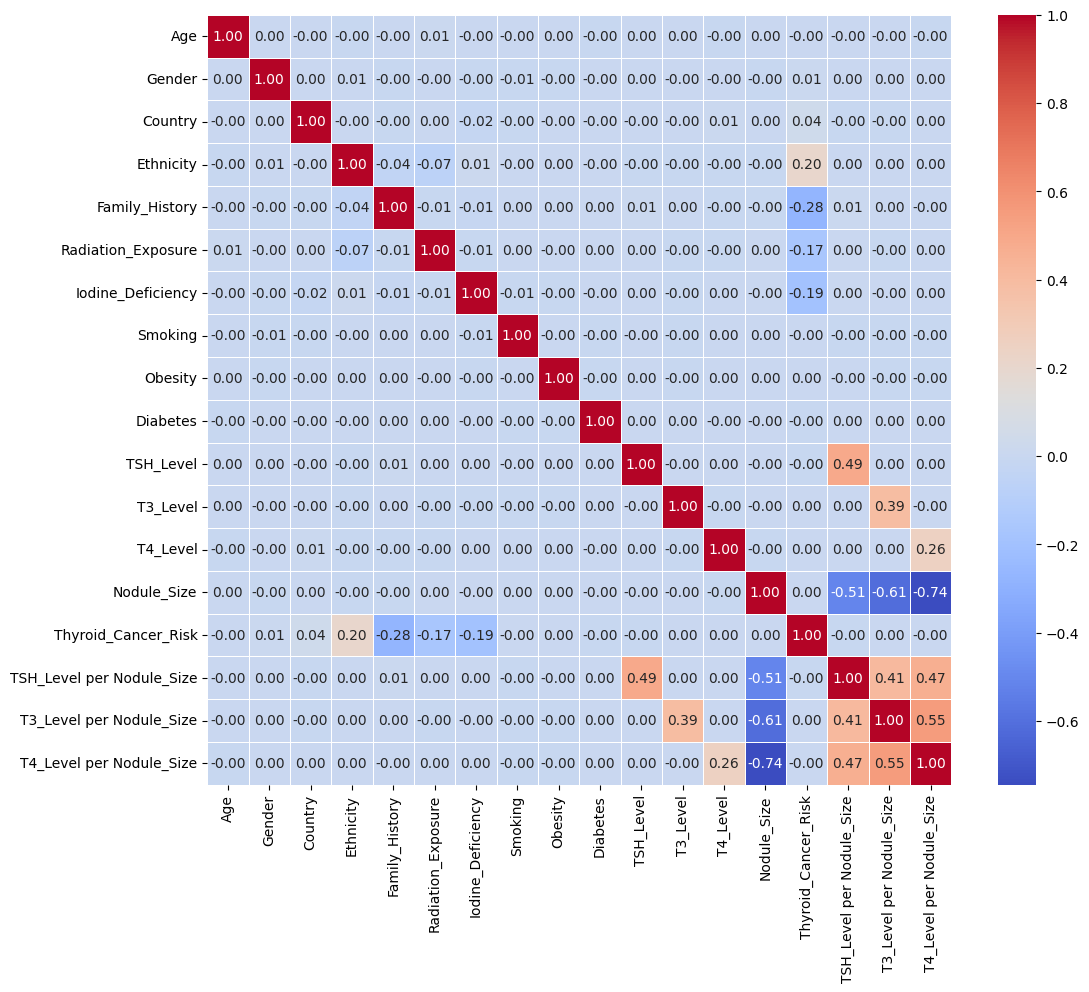

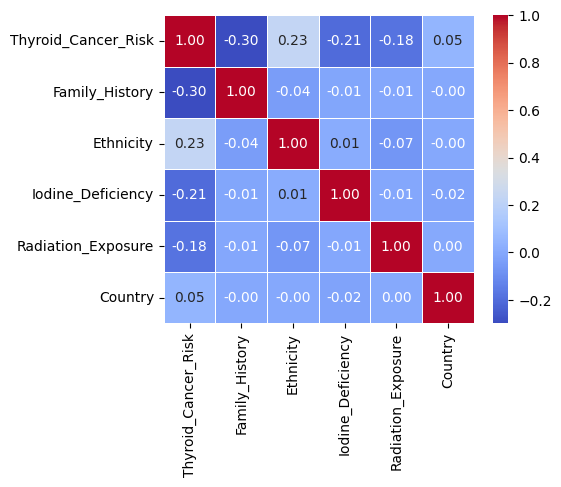

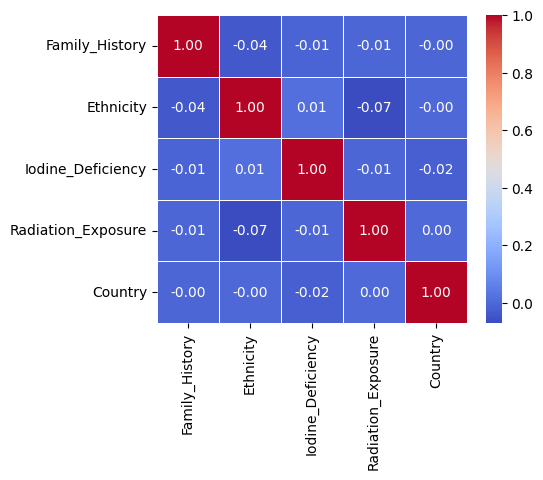

In [529]:
# Feature Engineering -> Feature Selection
# Relevant/Good: features(Independent/Input) --high +/-ve correlation--> target(Dependent/Output)
# Irrelevant/Bad: features(Independent/Input) --low near-0 correlation--> target(Dependent/Output)
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, f_classif

#Print the scores of all features in relation to target variable

for t in range(trgt_y.shape[1]):
    # 1. Fit the KBest selector
    KBest = SelectKBest(score_func=f_classif, k=18)   # Linear(f_regression|f_classif) to target; Nonlinear(mutual_info_regression|mutual_info_classif) to target
    output = KBest.fit_transform(feats_X, trgt_y.iloc[:,t])  # Fits to data & transform/reduce it to the selected features
    top_feats_X = pd.DataFrame(output, columns=KBest.get_feature_names_out())   # Transfrom numpy-array 2 pandas-dataframe
    
   # 2. Create Scroreboard to help Selection due to large number of features
    target_name = trgt_y.columns[t] 
    scores_df = pd.DataFrame({
        'Feature': feats_X.columns,
        'Score': KBest.scores_
    })
    
    # Sort the scoreboard from highest (best) to lowest (worst)
    scores_df = scores_df.sort_values(by='Score', ascending=False)
print(scores_df.head(12))


# AVOID Multi-Collinearity/Redundancy: features(Independent/Input) --high +/-ve correlation--> features(Independent/Input)
useful_feats_X = top_feats_X.loc[:, :]
useful_feats_corr = useful_feats_X.corr('kendall')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(12, 10))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch); (-ve corr., 0, +ve corr.)

print()
#Reshape the heatmap to focus on the top 6 features with highest scores and lowest correlation with each other
useful_feats_X = top_feats_X.loc[:, ["Thyroid_Cancer_Risk", "Family_History", "Ethnicity", "Iodine_Deficiency", "Radiation_Exposure", "Country"]] #['ppl_per_house', 'income_per_ppl'] important when "Oversampled" class >= 5000
useful_feats_corr = useful_feats_X.corr('pearson')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(5, 4))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch) => (-ve corr., 0, +ve corr.)

print()
#Removew the top feature "Thyroid_Cancer_Risk" to focus on the next 5 features with highest scores and lowest correlation with each other
useful_feats_X = top_feats_X.loc[:, ["Family_History", "Ethnicity", "Iodine_Deficiency", "Radiation_Exposure", "Country"]] #['ppl_per_house', 'income_per_ppl'] important when "Oversampled" class >= 5000
useful_feats_corr = useful_feats_X.corr('pearson')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(5, 4))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch) => (-ve corr., 0, +ve corr.)

In [530]:
# Training & Test Sets: StratifiedKFold + ShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit

X = useful_feats_X
y = trgt_y
print(X.shape)
print(y.shape, "\n")

strat_data = StratifiedShuffleSplit(n_splits=1, test_size=0.2, train_size=0.8)
for train_index, test_index in strat_data.split(X, y):
  X_train, y_train = X.iloc[train_index], y.iloc[train_index]
  X_test, y_test = X.iloc[test_index], y.iloc[test_index]
print("X_train:", X_train.shape, ",\t", "y_train:", y_train.shape)
print("X_test:", X_test.shape, ",\t", "y_test:", y_test.shape)

(98990, 5)
(98990, 1) 

X_train: (79192, 5) ,	 y_train: (79192, 1)
X_test: (19798, 5) ,	 y_test: (19798, 1)


In [531]:
# Fix P3: Feature Transformation/Scaling/Normalization of Features or Samples ("skewness/unsymmetric" dataset)
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer
import pandas as pd
import matplotlib.pyplot as plt

# Columns to split
nominal_cols = ["Family_History", "Ethnicity", "Iodine_Deficiency", "Radiation_Exposure", "Country"]

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=float)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=float)

# CRITICAL ALIGNMENT
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0.0)

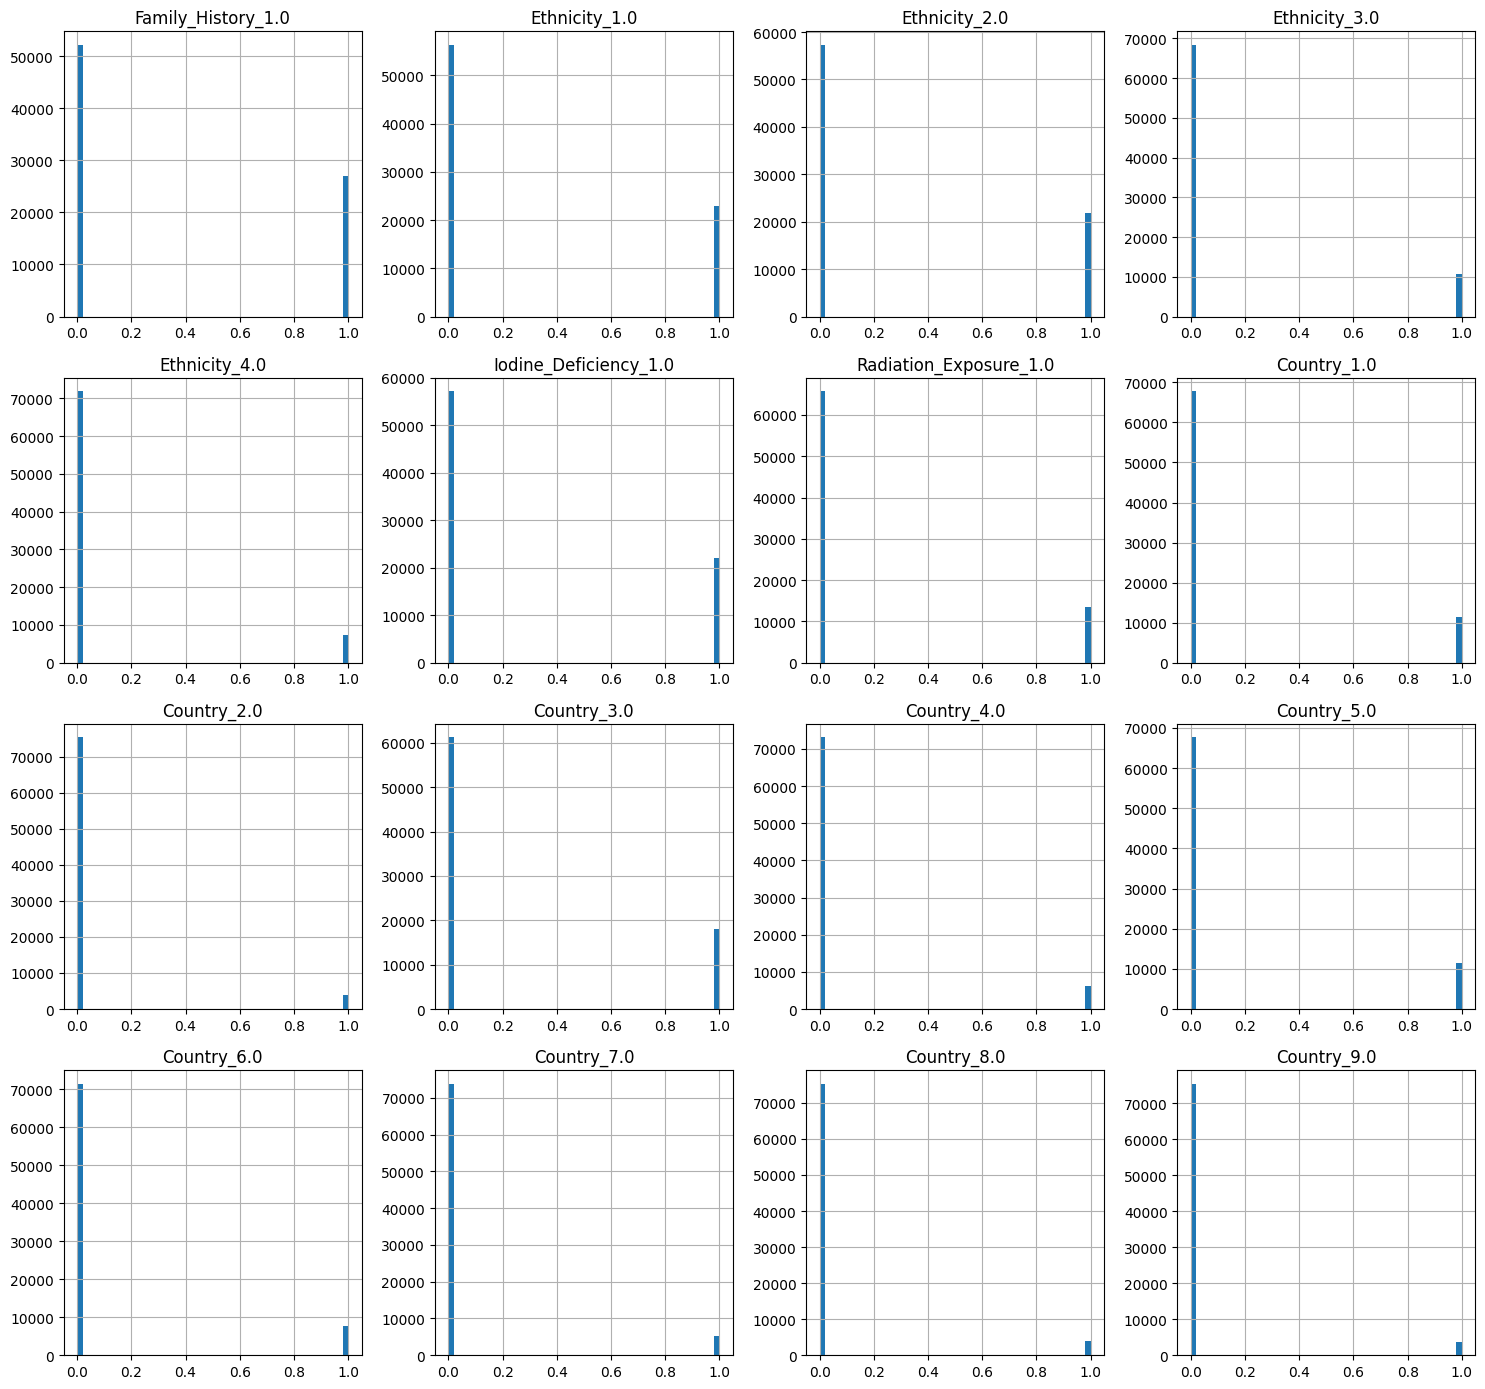

In [532]:
# Z-Score Normalization (or Standardization) wrt. Features/Columns: Non-Linear Transformation for 'feats_X'
quantile_trans_standzatn = QuantileTransformer(output_distribution='uniform')
quantile_trans_standzatn = quantile_trans_standzatn.fit(X_train)  # Fit ONLY on Train

standized_X_train = quantile_trans_standzatn.transform(X_train)
standized_X_test = quantile_trans_standzatn.transform(X_test)

# Z-Score Normalization (or Standardization) wrt. Features/Columns: Linear Transformation for 'trgt_y'
standized_y_train = y_train
standized_y_test = y_test

# Histrogram shows dataset WITHOUT 'skewness' (data is uniformly distributed)
pd.DataFrame(standized_X_train, columns=X_train.columns).hist(bins=50, figsize=(15, 14))
plt.tight_layout() 
plt.show()

In [533]:
# Algorithm Selection ----
# Import possible ML models
# Select ML model to test/use
# Select ML/DL algorithm AND Tune/Re-tune hyperparameters
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

ml_algorithm = "RandFrst"  # KNN, GradBoost, RandFrst, ExtraTree, DeciTree, etc

# Create if/then path to automatically import model and apply hyperparameters
if (ml_algorithm == "LinearRegress"):
  algorithm = LinearRegression()  # For regression only
elif (ml_algorithm == "LogisticRegress"):
  algorithm = LogisticRegression(solver='lbfgs')  # For classification only
elif (ml_algorithm == "SuppVec"):
  algorithm = SVC()
elif (ml_algorithm == "StochastGrad"):
  algorithm = SGDClassifier(learning_rate='invscaling', eta0=0.01)
elif (ml_algorithm == "Gaussian_N_Bayes"):
  algorithm = GaussianNB()
elif (ml_algorithm == "Multinomial_N_Bayes"):
  algorithm = MultinomialNB()
elif (ml_algorithm == "Bernoulli_N_Bayes"):
  algorithm = BernoulliNB()
elif (ml_algorithm == "Categorical_N_Bayes"):
  algorithm = CategoricalNB()
elif (ml_algorithm == "GradBoost"):
  algorithm = GradientBoostingClassifier()
elif (ml_algorithm == "DeciTree"):
  algorithm = DecisionTreeClassifier()
elif (ml_algorithm == "RandFrst"):
  algorithm = RandomForestClassifier(n_estimators=100)
elif (ml_algorithm == "ExtraTree"):
  algorithm = ExtraTreesClassifier(n_estimators=100)
elif (ml_algorithm == "KNN"):
  algorithm = KNeighborsClassifier(n_neighbors=6, weights='distance')
elif (ml_algorithm == "DL_MLP"):
  algorithm = MLPClassifier(hidden_layer_sizes=(standized_X_train.shape[1], 30, 50, 10, standized_y_train.shape[1]), activation='relu', solver='lbfgs', learning_rate='constant', learning_rate_init=0.001)

In [534]:
# TRAINING: K-Fold Cross-Validation. Fit algorithm(ML) to data(Training).
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, matthews_corrcoef

# Get probabilities instead of direct predictions
cv_preds_proba = cross_val_predict(algorithm, standized_X_train, standized_y_train.values.ravel(), cv=3, method='predict_proba')
print("Shape of Output/Probabilities: ", cv_preds_proba.shape, "\n")

#Tune threshold to prioritize recall
threshold = 0.379
cv_preds = (cv_preds_proba[:, 1] > threshold).astype(int)  # Classify as positive if prob > threshold

reversed_y_train = pd.DataFrame(cv_preds)
reversed_y_train = np.rint(reversed_y_train).astype(np.int32)

# Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR).
raw_y_train = y_train.values.ravel()
acc = accuracy_score(raw_y_train, reversed_y_train, normalize=True)  # normalize=True(fraction of correctly classified samples); normalize=False(no. of correctly classified samples)
pr_rc_fs_sp = precision_recall_fscore_support(raw_y_train, reversed_y_train, average='weighted')  # average='weighted'(compute metrics per label, and find their avg. weighted by support (no. of true instances per label))
mcc = matthews_corrcoef(raw_y_train, reversed_y_train)
# Note: ROC AUC uses probabilities directly, no threshold needed
roc = roc_auc_score(raw_y_train, cv_preds_proba[:, 1], average='weighted', multi_class='ovo')  # multi_class='ovo'(meaning One-vs-one. Computes avg. AUC of all possible pairwise combinations of classes)

# Training/Validation Metrics
print("Training Metrics: ", "\n----------------")
print("ACCURACY: ", acc)
print("PRECISION: ", pr_rc_fs_sp[0])
print("RECALL: ", pr_rc_fs_sp[1])  # This should be higher now
print("F1-SCORE: ", pr_rc_fs_sp[2])
print("AREA under ROC: ", roc)
print("MCC: ", mcc)

Shape of Output/Probabilities:  (79192, 2) 

Training Metrics:  
----------------
ACCURACY:  0.6240529346398627
PRECISION:  0.6242086549481877
RECALL:  0.6240529346398627
F1-SCORE:  0.6239350665504542
AREA under ROC:  0.6932921729081871
MCC:  0.24826154075082002


Testing Metrics:  
----------------
ACCURACY:  0.6269320133346803
PRECISION:  0.627119338519187
RECALL:  0.6269320133346803
F1-SCORE:  0.6267945228755659
AREA under ROC:  0.6981371841455861
MCC:  0.2540512827915905


Text(77.92222222222227, 0.5, 'Groundtruth (Polarity) Labels')

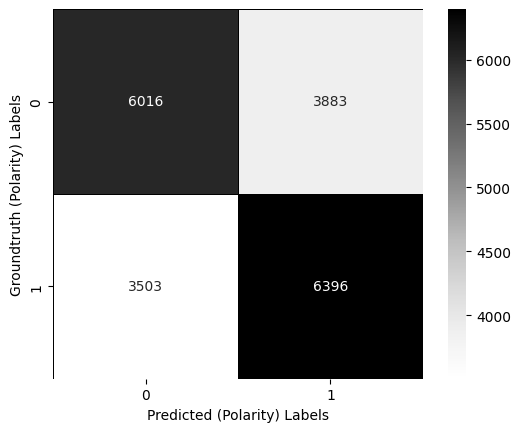

In [535]:
# TESTING/GENERALIZATION: Make Predictions for 'y-component' wrt. data(Test)
model = algorithm
model.fit(standized_X_train, standized_y_train.values.ravel())

# Get probabilities for test set
pred_proba_test = model.predict_proba(standized_X_test)

threshold = 0.379  # Match the training threshold
pred_y_test = (pred_proba_test[:, 1] > threshold).astype(int)

reversed_y_test = pd.DataFrame(pred_y_test)
reversed_y_test = np.rint(reversed_y_test).astype(np.int32)

# Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR).
raw_y_test = y_test.values.ravel()
acc = accuracy_score(raw_y_test, reversed_y_test, normalize=True)  # normalize=True(fraction of correctly classified samples); normalize=False(no. of correctly classified samples)
pr_rc_fs_sp = precision_recall_fscore_support(raw_y_test, reversed_y_test, average='weighted')  # average='weighted'(compute metrics per label, and find their avg. weighted by support (no. of true instances per label))
mcc = matthews_corrcoef(raw_y_test, reversed_y_test)
# ROC AUC uses probabilities
roc = roc_auc_score(raw_y_test, pred_proba_test[:, 1], average='weighted', multi_class='ovo')  # multi_class='ovo'(meaning One-vs-one. Computes avg. AUC of all possible pairwise combinations of classes)

# Testing Metrics
print("Testing Metrics: ", "\n----------------")
print("ACCURACY: ", acc)
print("PRECISION: ", pr_rc_fs_sp[0])
print("RECALL: ", pr_rc_fs_sp[1])  # This should be higher now
print("F1-SCORE: ", pr_rc_fs_sp[2])
print("AREA under ROC: ", roc)
print("MCC: ", mcc)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(raw_y_test, reversed_y_test)
classes = [0, 1]
ax = sbn.heatmap(cm, annot=True, fmt="d", cmap="Grays", cbar=True, linewidths=0.7, linecolor="black", square=True)
ax.set_xlabel("Predicted (Polarity) Labels")
ax.set_ylabel("Groundtruth (Polarity) Labels")